In [31]:
import sys
sys.path.insert(0, "../")
import warnings
import pystac
import fsspec
import cartopy
import math
import calendar
import pandas as pd

import xarray as xr
import zarr
import matplotlib.pyplot as plt
from pprint import pprint
import json

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import copernicusmarine
from reefwatch import fetch
from reefwatch.constants import KELVIN_TO_CELSIUS
from reefwatch.constants import BASELINE_START, BASELINE_END
from reefwatch.constants import ANALYSIS_START, ANALYSIS_END
from reefwatch.fetch import REGIONS

warnings.simplefilter("ignore", RuntimeWarning)

In [32]:
print(json.dumps(REGIONS, indent=2))
print(BASELINE_START, BASELINE_END)
print(ANALYSIS_START, ANALYSIS_END)

NameError: name 'REGIONS' is not defined

In [2]:
ds = fetch.fetch_data("red_sea", "2023-01-01", "2023-12-01")
ds["analysed_sst"]

INFO - 2026-08-17T11:46:09Z - Selected dataset version: "202506"
INFO - 2026-08-17T11:46:09Z - Selected dataset part: "default"


<xarray.DataArray 'analysed_sst' (time: 335, latitude: 360, longitude: 230)> Size: 222MB
dask.array<rechunk-merge, shape=(335, 360, 230), dtype=float64, chunksize=(335, 160, 64), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-01
  * latitude   (latitude) float32 1kB 12.03 12.08 12.13 ... 29.88 29.93 29.98
  * longitude  (longitude) float32 920B 32.02 32.07 32.12 ... 43.37 43.42 43.47
Attributes:
    comment:        The under-ice SST is the freezing point temperature TS, c...
    long_name:      analysed sea and under-ice surface temperature
    source:         AASTI v2 SST/IST, ESA CCI SST and C3S SST L2P products
    standard_name:  sea_surface_temperature
    units:          kelvin
    valid_range:    [-6000  4500]

In [11]:
avg_sst_overspace = ds["analysed_sst"].sel(time="2023-01-01").mean(
    dim=["latitude", "longitude"]).compute()
print (avg_sst_overspace.values + KELVIN_TO_CELSIUS)

26.537961864378644


In [4]:
avg_sst_overtime = ds["analysed_sst"].mean(dim="time")
sst_celsius = avg_sst_overtime.compute() + KELVIN_TO_CELSIUS
vmin = math.floor(float(sst_celsius.min().values))
vmax = math.ceil(float(sst_celsius.max().values))

In [5]:
sst_celsius.attrs["long_name"] = "Sea Surface Temperature"
sst_celsius.attrs["units"] = "\u00b0C"
pprint(sst_celsius.attrs)

{'comment': 'The under-ice SST is the freezing point temperature TS, computed '
            'as in Banzon et al. (2020), using Millero’s formula (Fofonoff and '
            'Millard, 1983) and the World Ocean Atlas 2018 salinity '
            'climatology (Garcia et al., 2019) and further adjusted by a '
            'constant C and the sea ice concentration SIC.',
 'long_name': 'Sea Surface Temperature',
 'source': 'AASTI v2 SST/IST, ESA CCI SST and C3S SST L2P products',
 'standard_name': 'sea_surface_temperature',
 'units': '°C',
 'valid_range': array([-6000,  4500], dtype=int16)}


# Projections:
* PlateCarree — simple rectangular lat/lon grid. Good for regional maps where distortion isn't a big issue. Easy to work with because coordinates map directly to x/y.
- Mercator — preserves shapes but distorts size (Greenland looks as big as Africa). Good for navigation, bad for showing area accurately.
* LambertConformal — preserves shapes locally, good for mid-latitude regional maps (e.g. USA, Europe). Commonly used in weather forecasting.
* Mollweide — equal area, good for global maps showing distributions. Oval shape.
* Orthographic — looks like a globe viewed from space. Good for showing a hemisphere dramatically.
* Robinson — compromise projection, commonly used for world maps in atlases.

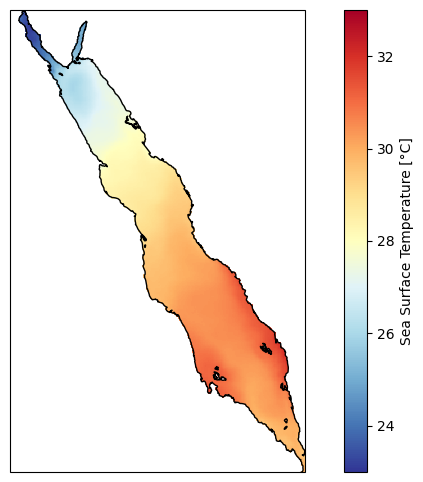

In [6]:
# Use xarray's .plot() for quick exploration plots, to see how the data looks.
# One line, automatic labels, good enough for checking your data looks right.

fig, ax = plt.subplots(
    figsize=(10,6), dpi=100, 
    subplot_kw=dict(projection = ccrs.PlateCarree()))
sst_celsius.plot(cmap="RdYlBu_r",
                vmin=vmin,
                vmax=vmax)
ax.coastlines()

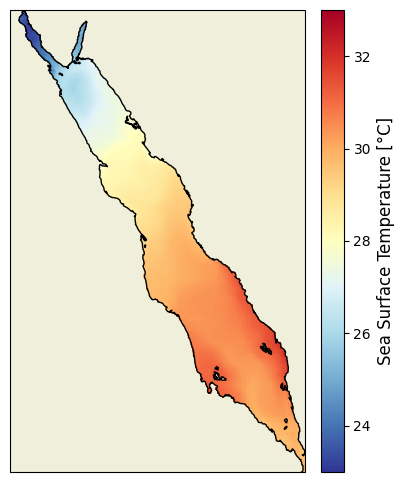

In [7]:
# ax.pcolormesh() with cartopy — better for final outputs. 
# For proper map projections, coastlines, gridlines, 
# full control over every visual element. 

fig, ax = plt.subplots(
    figsize=(10,6), dpi=100, subplot_kw={"projection": 
                                         ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND)
mesh = ax.pcolormesh(sst_celsius.longitude, sst_celsius.latitude,
              sst_celsius.values, transform=ccrs.PlateCarree(),
             cmap="RdYlBu_r", vmin=vmin, vmax=vmax)
cbar = plt.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label(sst_celsius.long_name + f" [{sst_celsius.units}]", fontsize=12)
cbar.ax.tick_params(labelsize=10)

In [8]:
historical = fetch.fetch_data("red_sea", "1991-01-01", "2020-12-31")
historical_monthly = (historical["analysed_sst"]
                      .mean(dim=["latitude", "longitude"])
                      .groupby("time.month").mean()
                      .compute()) + KELVIN_TO_CELSIUS

INFO - 2026-08-17T11:46:40Z - Selected dataset version: "202506"
INFO - 2026-08-17T11:46:40Z - Selected dataset part: "default"


In [10]:
# Calculate the highest mean temp per month and list the mean 
# temperatures each month for the last year
monthly_mean = (ds["analysed_sst"]
                .groupby("time.month").mean() 
                .mean(dim=["latitude", "longitude"])
                .compute()) + KELVIN_TO_CELSIUS
monthly_mean.attrs["units"] = "\u00b0C"
# Convert to DataFrame
print (monthly_mean.to_dataframe(name="SST (°C)"))

        SST (°C)
month           
1      26.052087
2      25.503380
3      25.981090
4      27.049638
5      29.079117
6      30.810631
7      31.472287
8      32.376284
9      32.023054
10     31.256263
11     29.758771
12     28.898901


In [28]:
df2 = pd.DataFrame({
    "2023 avg (°C)": (monthly_mean).round(2),
    "Deviatoin from 30yr mean temp (°C)": (monthly_mean - historical_monthly).round(2)
}, index=[calendar.month_name[m] for m in range(1,13)])
df2.index.name = "Month"
df2

,2023 avg (°C),Deviatoin from 30yr mean temp (°C)
Month,,
January,26.05,0.42
February,25.50,0.47
March,25.98,0.63
April,27.05,0.46
May,29.08,0.64
June,30.81,1.44
July,31.47,1.07
August,32.38,1.38
September,32.02,1.15
